In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from jax_grid import Grid, gg_space, softmax, glob_inh, sigmoid
from tqdm import tqdm
import matplotlib.pyplot as plt

## Grid only

In [28]:
exc_range = np.arange(0, 101)
inh_range = np.arange(0, -101, -1)
lambdas = np.array([3,4,5])
Ng = np.sum(lambdas**2)

wggs = gg_space(Ng, lambdas, exc_range, inh_range, '/home/srujana/VSCode Projects/Thesis/g2g_space.npy')
print('saved all weight matrices!')

saved all weight matrices!


In [25]:
print(wggs[2,1, :, :])

[[ 2. -1. -1. ...  0.  0.  0.]
 [-1.  2. -1. ...  0.  0.  0.]
 [-1. -1.  2. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  2. -1. -1.]
 [ 0.  0.  0. ... -1.  2. -1.]
 [ 0.  0.  0. ... -1. -1.  2.]]


### Softmax

In [ ]:
lambdas = np.array([3, 4, 5])
lambdas_static = tuple(int(l) for l in lambdas)

# g0 only depends on lambdas, not on W_gg — build it once
g0_jax = jnp.asarray(Grid(lambdas, 'sigmoid', gg_exc=0, gg_inh=0).grid)

wggs = np.load('g2g_space.npy')                              # (100, 100, Ng, Ng)
wggs_flat = jnp.asarray(wggs).reshape(-1, *wggs.shape[-2:])  # (10000, Ng, Ng)

# vmap the *already-jitted* pure staticmethod over the leading axis of W_gg only.
# g0 / lambdas / tau_g / activation / dt are shared across the batch -> in_axes=None
vmapped_run = jax.jit(
    jax.vmap(Grid.simulate_run, in_axes=(None, {'W_gg': 0}, None, None, None, None)),
    static_argnames=('lambdas', 'activation'),
)

def score_all(activation_fn, chunk_size=500):
    chunks = []
    for start in tqdm(range(0, wggs_flat.shape[0], chunk_size)):
        batch = wggs_flat[start:start + chunk_size]
        final = vmapped_run(g0_jax, {'W_gg': batch}, lambdas_static, 1.0, activation_fn, 0.1)
        correct = jnp.all(jnp.abs(final - g0_jax[None]) <= 1e-1, axis=1)  # (chunk, patts)
        chunks.append(np.asarray(jnp.mean(correct, axis=1)))
    return np.concatenate(chunks).reshape(len(exc_range), len(inh_range))

fracs_q  = score_all(glob_inh)

 33%|███▎      | 7/21 [46:15<1:33:57, 402.68s/it]

In [ ]:
fracs = np.zeros((100, 100))
wggs = np.load('g2g_space.npy')

for i in tqdm(range(100)):
    for j in range(100):
        grid = Grid(lambdas, 'softmax', gg_default=False, W_gg=wggs[i, j, :, :])
        g0 = grid.grid
        final = grid.run(g0)

        fracs[i, j] = sum(np.allclose(final[:, p], g0[:, p], atol=1e-1) for p in range(3600)) / 3600

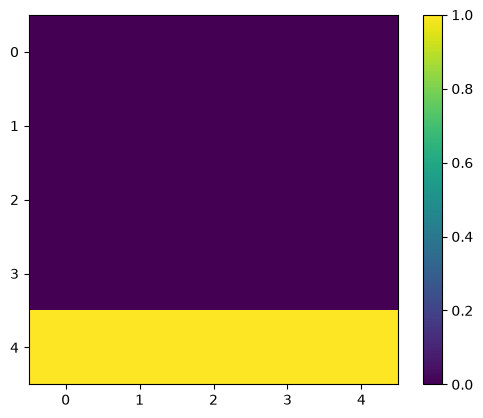

In [22]:
plt.imshow(fracs)
plt.colorbar()

### Quadratic normalization

In [ ]:
fracs_q = np.zeros((100, 100))
wggs = np.load('g2g_space.npy')

for i in tqdm(range(100)):
    for j in range(100):
        grid = Grid(lambdas, 'softmax', gg_default=False, W_gg=wggs[i, j, :, :])
        g0 = grid.grid
        final = grid.run(g0)

        fracs_q[i, j] = sum(np.allclose(final[:, p], g0[:, p], atol=1e-1) for p in range(3600)) / 3600

In [ ]:
plt.imshow(fracs)
plt.colorbar()

### Sigmoid

In [ ]:
fracs_sig = np.zeros((100, 100))
wggs = np.load('g2g_space.npy')

for i in tqdm(range(100)):
    for j in range(100):
        grid = Grid(lambdas, 'sigmoid', gg_default=False, W_gg=wggs[i, j, :, :])
        g0 = grid.grid
        final = grid.run(g0)

        fracs_sig[i, j] = sum(np.allclose(final[:, p], g0[:, p], atol=1e-1) for p in range(3600)) / 3600

In [ ]:
plt.imshow(fracs)
plt.colorbar()

## Scaffold

In [ ]:
lambdas = np.array([3,4,5])
scaffold = Scaffold(400, lambdas, 3, -0.5, gamma=0.6, b=0.5, dt=0.05)
h0 = scaffold.hc
g0 = scaffold.grid
final = scaffold.run(g0, h0)
n_correct = sum(np.allclose(final[1][:, p], h0[:, p], atol=5e-1) for p in range(3600))
print(n_correct)
print(final[0][:, 0])